In [1]:
import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

2025-04-12 08:29:29.773403: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-12 08:29:29.804012: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-12 08:29:29.804031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-12 08:29:29.805138: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 08:29:29.810788: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']

Egms models LOADED - var: **egms_all_models**, **egms_values** 
EGMS data normalized - var: **egms_filtered_norm** 
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [2]:
import scatt_all_models

Num GPUs Available:  2
All models have been trimmed to the minimum length - var: **bsps_64_filtered_models** 

Model: Simulation_01_210209_001_002
Samples of every node: 2000 samples
Shape del tensor de Simulation_01_210209_001_002: (64, 74, 125)

Model: LA_RSPV_CAF_150115
Samples of every node: 4000 samples
Shape del tensor de LA_RSPV_CAF_150115: (64, 74, 250)

Model: Simulation_01_200428_001_001
Samples of every node: 4000 samples
Shape del tensor de Simulation_01_200428_001_001: (64, 74, 250)

Model: Simulation_01_201223_001_002
Samples of every node: 2000 samples
Shape del tensor de Simulation_01_201223_001_002: (64, 74, 125)

Model: Simulation_01_190619_001_004
Samples of every node: 2000 samples
Shape del tensor de Simulation_01_190619_001_004: (64, 74, 125)

Model: Simulation_01_190502_001_004
Samples of every node: 2000 samples
Shape del tensor de Simulation_01_190502_001_004: (64, 74, 125)

Model: RA_RAFW_140807
Samples of every node: 2000 samples
Shape del tensor de RA_RAFW_1

In [31]:
egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices

sinusal_groups = scatt_all_models.sinusal_groups
rotor_simple_groups = scatt_all_models.rotor_simple_groups
rotor_complejo_groups = scatt_all_models.rotor_complejo_groups
models_name = scatt_all_models.models_name


In [99]:

for i in range(len(bsps_all_models)):
    bsps_64 = bsps_all_models[i]


    
filtered_models = []  # Lista para almacenar los modelos procesados

for model in bsps_64_all_models:
    new_model = []  # Lista para almacenar los nodos filtrados y recortados
    
    for node in model:
        original_length = len(node)  # Longitud original del nodo

        # Descartar los nodos menores de 2000 samples
        if original_length < 2000:
            continue  # No agregar este nodo a new_model

        # Recortar nodos entre 2001 y 2500 samples a 2000
        if 2001 <= original_length <= 2500:
            node = node[:2000]

        # Recortar nodos entre 4001 y 4501 samples a 4000
        elif 4001 <= original_length <= 4501:
            node = node[:4000]

        # Agregar el nodo procesado a la lista del modelo
        new_model.append(node)

    # Solo agregar el modelo si aún tiene nodos después del filtrado
    if len(new_model) > 0:
        filtered_models.append(new_model)
    else:
        continue


    bsps_64_filtered_models = filtered_models



In [100]:
labels = []
print(len(bsps_64_filtered_models))
for model, name_model in zip(bsps_64_filtered_models, models_name):
    if name_model in sinusal_groups:
        print(f"Model {name_model} is a sinusal group")
        labels.append(0)
    elif name_model in rotor_simple_groups:
        print(f"Model {name_model} is a rotor simple group")
        labels.append(1)
    elif name_model in rotor_complejo_groups:
        print(f"Model {name_model} is a rotor complejo group")
        labels.append(1)
    else:
        print(f"Model {name_model} is not in any group --> AF")
        labels.append(1)


9
Model Simulation_01_210209_001_002 is a sinusal group
Model LA_RSPV_CAF_150115 is a rotor complejo group
Model Simulation_01_200428_001_001 is a sinusal group
Model Simulation_01_201223_001_002 is a sinusal group
Model Simulation_01_190619_001_004 is not in any group --> AF
Model Simulation_01_190502_001_004 is not in any group --> AF
Model RA_RAFW_140807 is a rotor complejo group
Model RA_RAA_141230 is a rotor complejo group
Model Simulation_01_200316_001_  1 is a sinusal group


In [101]:
import numpy as np

X_train = []
X_test = []
y_train = []
y_test = []

model_labels = labels  # Etiquetas de los modelos originales

for i, model in enumerate(bsps_64_filtered_models):
    label = model_labels[i]  # Obtener la etiqueta del modelo original
    model = np.array(model)  # Convierte a array si es una lista


    if model.shape[1] == 2000:  # Modelos con nodos de 125 muestras
        # Dividir en segmentos de 63 para train y test
        train = model[:, :1000]  # Primeras 63 muestras
        test = model[:,  1000:]   # Siguientes 62 muestras (total 125, por lo que la parte de test tiene 62)

        # Agregar segmentos a X
        X_train.append(train)
        X_test.append(test)

        # Agregar las etiquetas correspondientes
        y_train.append(label)  
        y_test.append(label)   

    elif model.shape[1] == 4000:  # Modelos con nodos de 250 muestras

        train1 = model[:, 0:1000]
        test1 = model[:, 1000:2000]
        train2 = model[:, 2000:3000]
        test2 = model[:,  3000:4000]

        # Agregar segmentos a X
        X_train.append(train1)
        X_train.append(train2)
        X_test.append(test1)
        X_test.append(test2)

        # Etiquetas duplicadas para los dos nuevos modelos de 125 muestras
        y_train.append(label)  # Etiqueta para el primer modelo de 125 muestras
        y_train.append(label)  # Etiqueta para el segundo modelo de 125 muestras
        y_test.append(label)   # Etiqueta para el primer modelo de 125 muestras
        y_test.append(label)   # Etiqueta para el segundo modelo de 125 muestras

    else:
        print(f" Modelo con longitud inesperada: {model.shape}")
        continue  # Saltar modelos con una duración inesperada

# Convertir listas de X y y en arrays numpy
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Verificar las dimensiones de las matrices resultantes
print(f"Shape de X_train: {X_train.shape}") 
print(f"Shape de X_test: {X_test.shape}")    
print(f"Shape de y_train: {y_train.shape}")  
print(f"Shape de y_test: {y_test.shape}")    

print(labels)
print(y_train)
print(y_test)


Shape de X_train: (12, 64, 1000)
Shape de X_test: (12, 64, 1000)
Shape de y_train: (12,)
Shape de y_test: (12,)
[0, 1, 0, 0, 1, 1, 1, 1, 0]
[0 1 1 0 0 0 1 1 1 1 0 0]
[0 1 1 0 0 0 1 1 1 1 0 0]


(64, 1000)


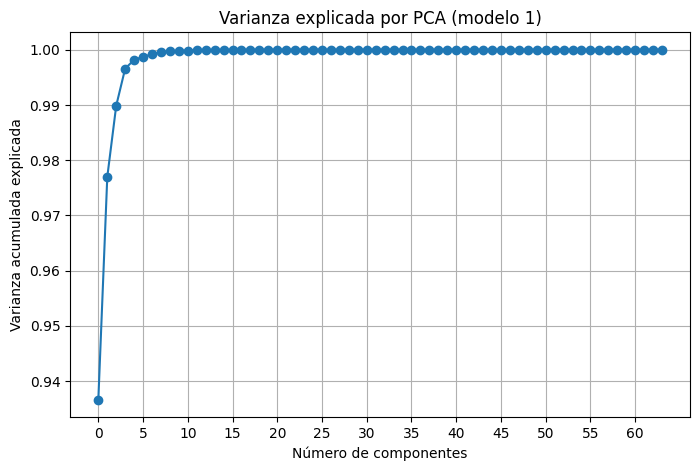

In [108]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

model = X_train[2]  # Un modelo: shape (64 nodos, 1000 muestras)
print(model.shape)
pca = PCA()
pca.fit(model)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')

# Personalizar el eje x para mostrar más marcas
plt.xticks(np.arange(0, len(explained_variance), step=5))  # Ajustar el paso según lo necesites

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por PCA (modelo 1)')
plt.grid(True)
plt.show()


PCA

In [109]:
from sklearn.decomposition import PCA

n_components = 3
X_train_pca = []
X_test_pca = []

for dataset in [X_train, X_test]:
    X_pca_set = []

    for model in dataset:  # model.shape: (64, 1000)
        
        # Transponer a (1000, 64) para que las features sean los nodos
        model_T = model.T
        pca = PCA(n_components=n_components)
        model_pca = pca.fit_transform(model_T)  # (1000, 3)

        # Si quieres devolverlo como (64, 3) puedes transponer de nuevo
        model_pca = model_pca.T  # (3, 1000)
        print(model_pca.shape)
        X_pca_set.append(model_pca)

    if dataset is X_train:
        X_train_pca = X_pca_set
    else:
        X_test_pca = X_pca_set

print(f"✅ PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} (3 componentes x 1000 muestras)")




(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
(3, 1000)
✅ PCA aplicado por modelo. Ejemplo dimensiones: (3, 1000) (3 componentes x 1000 muestras)


In [110]:
X_train = np.array(X_train_pca)
X_test = np.array(X_test_pca)
y_train = np.array(y_train)
y_test = np.array(y_test)
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (12, 3, 1000)
Shape de X_test: (12, 3, 1000)
Shape de y_train: (12,)
Shape de y_test: (12,)


In [112]:
from kymatio import Scattering1D

J = 4
Q = (16,1)
ws_coeff_all_mods = []  # list to store the wavelet scattering coefficients for all models --> 12 tensors of 64 nodes
ws_coeff_all_train_mods = []  # list to store the wavelet scattering coefficients for all models --> 12 tensors of 64 nodes
ws_coeff_all_test_mods = []  # list to store the wavelet scattering coefficients for all models --> 12 tensors of 64 nodes 

models_shortened = [X_train, X_test]

# Aplicar wavelet scattering a los todos los nodos de los 2 modelos (simple y complex)
for i in range(len(models_shortened)):
    for model in models_shortened[i]:
        
        print("Samples of every node:", len(model[0]), "samples")

        model_coeffs = []  # Lista temporal para guardar los coeficientes de los 64 nodos
        
        for j in range(len(model)):
            signal = np.array(model[j])  # Asegurar que es un array de numpy
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  # Aplicar wavelet scattering
            
            model_coeffs.append(Sx)  # Guardar el coeficiente de este nodo
        
        if i == 0:
            ws_coeff_all_train_mods.append(np.stack(model_coeffs))
        elif i == 1:
            ws_coeff_all_test_mods.append(np.stack(model_coeffs))
        ws_coeff_all_mods.append(np.stack(model_coeffs))  # Convertir en tensor y añadirlo a la lista principal
        print(f"Shape del tensor: {ws_coeff_all_mods[-1].shape}")

print("Wavelet scattering coefficients for all models (24 tensors) - var: **ws_coeff_all_mods** ")

Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of every node: 1000 samples
Shape del tensor: (3, 74, 63)
Samples of

In [113]:
print(f"Shape de ws_coeff_all_mods: {(ws_coeff_all_mods[0]).shape}")  # (64, 3, 1000) --> 64 nodos, 3 componentes, 1000 muestras
print(f"Shape de ws_coeff_all_train_mods: {ws_coeff_all_train_mods[0].shape}")  # (64, 3, 1000) --> 64 nodos, 3 componentes, 1000 muestras
print(f"Shape de ws_coeff_all_test_mods: {ws_coeff_all_test_mods[0].shape}")  # (64, 3, 1000) --> 64 nodos, 3 componentes, 1000 muestras

Shape de ws_coeff_all_mods: (3, 74, 63)
Shape de ws_coeff_all_train_mods: (3, 74, 63)
Shape de ws_coeff_all_test_mods: (3, 74, 63)


In [114]:
X_train = np.array(ws_coeff_all_train_mods)
X_test = np.array(ws_coeff_all_test_mods)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"Shape de X_train: {X_train.shape}") 
print(f"Shape de X_test: {X_test.shape}")  
print(f"Shape de y_train: {y_train.shape}")  # (12,) --> 12 etiquetas
print(f"Shape de y_test: {y_test.shape}")  # (12,) --> 12 etiquetas

Shape de X_train: (12, 3, 74, 63)
Shape de X_test: (12, 3, 74, 63)
Shape de y_train: (12,)
Shape de y_test: (12,)


In [115]:
X_train_flat = X_train.reshape((X_train.shape[0], -1))  # (12, 3*74*63)
X_test_flat = X_test.reshape((X_test.shape[0], -1))     # (12, 3*74*63)
print(f"Shape de X_train_flat: {X_train_flat.shape}")
print(f"Shape de X_test_flat: {X_test_flat.shape}")


Shape de X_train_flat: (12, 13986)
Shape de X_test_flat: (12, 13986)


In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf.fit(X_train_flat, y_train)

y_pred = rf.predict(X_test_flat)

print("✅ Resultados del Random Forest:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


✅ Resultados del Random Forest:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.67      0.67      0.67         6

    accuracy                           0.67        12
   macro avg       0.67      0.67      0.67        12
weighted avg       0.67      0.67      0.67        12

Accuracy: 0.6666666666666666
